# 33kV Incoming Feeder, Cashflow, and Bihar Generation Extension

This notebook extends the existing feeder report with a Bihar scheduled-generation context layer.

Guardrails for this extension:

- keep the original feeder report as the baseline and add a comparison layer on top
- compare profile shape and timing before comparing raw magnitude
- treat the Bihar series as scheduled generation context, not proven actual metered generation
- only use the overlap window where both feeder and Bihar generation data are available
- keep the merged output easy to reuse for markdown reporting

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def find_project_root(start: Path | None = None) -> Path:
    start_path = (start or Path.cwd()).resolve()
    for candidate in [start_path, *start_path.parents]:
        if (candidate / 'src').exists() and (candidate / 'config').exists():
            return candidate
    raise FileNotFoundError('Could not locate the project root containing src/ and config/.')


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.path_utils import ensure_project_directories, load_app_config, resolve_project_paths

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

print(f'Project root: {PROJECT_ROOT}')

Project root: F:\Secure\CashFlowMgmt


In [2]:
APP_CONFIG = load_app_config(PROJECT_ROOT / 'config' / 'app_config.yaml')
PATHS = resolve_project_paths(cli_base_dir=PROJECT_ROOT, app_config=APP_CONFIG)
ensure_project_directories(PATHS)

DATA_DIR = PROJECT_ROOT / 'data'
OUTPUT_DIR = PATHS.processed_data_dir / '33kv_generation_extension'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FEEDER_SUMMARY_PATH = DATA_DIR / '33kv_incoming_feeder_daily_summary.xlsx'
BIHAR_GENERATION_PATH = PATHS.processed_data_dir / 'bihar_energy_flow' / 'daily_bihar_generation.csv'
BIHAR_EXPORT_PATH = PATHS.processed_data_dir / 'bihar_energy_flow' / 'daily_bihar_to_interstate.csv'
BIHAR_IMPORT_PATH = PATHS.processed_data_dir / 'bihar_energy_flow' / 'daily_interstate_to_bihar.csv'

OVERLAP_CSV_PATH = OUTPUT_DIR / '33kv_generation_overlap_daily.csv'
OVERLAP_SUMMARY_CSV_PATH = OUTPUT_DIR / '33kv_generation_overlap_summary.csv'
WEEKDAY_PROFILE_CSV_PATH = OUTPUT_DIR / '33kv_generation_overlap_weekday_profile.csv'
CORRELATION_CSV_PATH = OUTPUT_DIR / '33kv_generation_overlap_correlation.csv'

GENERATION_DAILY_CHART_PATH = DATA_DIR / '33kv_incoming_feeder_generation_daily_context.png'
INDEXED_CHART_PATH = DATA_DIR / '33kv_incoming_feeder_generation_indexed_overlap.png'
WEEKDAY_CHART_PATH = DATA_DIR / '33kv_incoming_feeder_generation_weekday_profile.png'
CORRELATION_CHART_PATH = DATA_DIR / '33kv_incoming_feeder_generation_correlation.png'
GEN_VS_FEEDER_SCATTER_PATH = DATA_DIR / '33kv_incoming_feeder_generation_vs_feeder_scatter.png'
GEN_VS_VEND_SCATTER_PATH = DATA_DIR / '33kv_incoming_feeder_generation_vs_vend_scatter.png'

required_paths = [FEEDER_SUMMARY_PATH, BIHAR_GENERATION_PATH]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError('Missing required inputs: ' + ', '.join(str(path) for path in missing_paths))

for label, path in {
    'feeder_summary': FEEDER_SUMMARY_PATH,
    'bihar_generation': BIHAR_GENERATION_PATH,
    'bihar_export': BIHAR_EXPORT_PATH,
    'bihar_import': BIHAR_IMPORT_PATH,
    'output_dir': OUTPUT_DIR,
}.items():
    print(f'- {label}: {path} [{"FOUND" if path.exists() else "MISSING"}]')

- feeder_summary: F:\Secure\CashFlowMgmt\data\33kv_incoming_feeder_daily_summary.xlsx [FOUND]
- bihar_generation: F:\Secure\CashFlowMgmt\data\processed\bihar_energy_flow\daily_bihar_generation.csv [FOUND]
- bihar_export: F:\Secure\CashFlowMgmt\data\processed\bihar_energy_flow\daily_bihar_to_interstate.csv [FOUND]
- bihar_import: F:\Secure\CashFlowMgmt\data\processed\bihar_energy_flow\daily_interstate_to_bihar.csv [FOUND]
- output_dir: F:\Secure\CashFlowMgmt\data\processed\33kv_generation_extension [FOUND]


In [3]:
DAY_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
ANALYSIS_START = pd.Timestamp('2025-04-01')
ANALYSIS_END = pd.Timestamp('2026-03-31')


def coefficient_of_variation(mean_value: float, std_value: float) -> float:
    if pd.isna(mean_value) or pd.isna(std_value) or mean_value == 0:
        return np.nan
    return float(std_value) / float(mean_value)



def index_to_mean_100(series: pd.Series) -> pd.Series:
    valid_mean = series.dropna().mean()
    if pd.isna(valid_mean) or valid_mean == 0:
        return pd.Series(np.nan, index=series.index)
    return (series / valid_mean) * 100.0



def zscore_series(series: pd.Series) -> pd.Series:
    valid_std = series.dropna().std()
    valid_mean = series.dropna().mean()
    if pd.isna(valid_std) or valid_std == 0:
        return pd.Series(np.nan, index=series.index)
    return (series - valid_mean) / valid_std



def save_line_chart(path: Path) -> None:
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved chart: {path}')



def render_corr_heatmap(corr_df: pd.DataFrame, title: str, output_path: Path) -> None:
    fig, ax = plt.subplots(figsize=(7, 6))
    image = ax.imshow(corr_df.to_numpy(), cmap='coolwarm', vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr_df.columns)))
    ax.set_xticklabels(corr_df.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(corr_df.index)))
    ax.set_yticklabels(corr_df.index)
    ax.set_title(title)
    for i in range(len(corr_df.index)):
        for j in range(len(corr_df.columns)):
            value = corr_df.iloc[i, j]
            ax.text(j, i, f'{value:.2f}', ha='center', va='center', color='black')
    fig.colorbar(image, ax=ax, shrink=0.85)
    save_line_chart(output_path)

In [4]:
feeder_daily = pd.read_excel(FEEDER_SUMMARY_PATH, engine='openpyxl')
feeder_daily = feeder_daily.rename(columns={'Rs/kWh': 'rs_per_kwh'})
feeder_daily['date'] = pd.to_datetime(feeder_daily['date'], errors='coerce')
feeder_daily = feeder_daily.loc[feeder_daily['date'].between(ANALYSIS_START, ANALYSIS_END, inclusive='both')].copy()
feeder_daily['rs_per_kwh'] = feeder_daily['vend_amount'] / feeder_daily['kWh']
feeder_daily.loc[feeder_daily['kWh'].isna() | (feeder_daily['kWh'] == 0), 'rs_per_kwh'] = pd.NA
feeder_daily['feeder_mwh'] = feeder_daily['kWh'] / 1000.0

bihar_generation_daily = pd.read_csv(BIHAR_GENERATION_PATH)
bihar_generation_daily['date'] = pd.to_datetime(bihar_generation_daily['sch_date'], errors='coerce')
bihar_generation_daily = bihar_generation_daily.rename(columns={'scheduled_energy_mwh': 'bihar_generation_sched_mwh'})
bihar_generation_daily = bihar_generation_daily[['date', 'bihar_generation_sched_mwh', 'source_rows', 'ambiguous_rows']].copy()

bihar_export_daily = None
if BIHAR_EXPORT_PATH.exists():
    bihar_export_daily = pd.read_csv(BIHAR_EXPORT_PATH)
    if not bihar_export_daily.empty:
        bihar_export_daily['date'] = pd.to_datetime(bihar_export_daily['sch_date'], errors='coerce')
        bihar_export_daily = bihar_export_daily.rename(columns={'scheduled_energy_mwh': 'bihar_export_sched_mwh'})[['date', 'bihar_export_sched_mwh']]

bihar_import_daily = None
if BIHAR_IMPORT_PATH.exists():
    bihar_import_daily = pd.read_csv(BIHAR_IMPORT_PATH)
    if bihar_import_daily.empty:
        bihar_import_daily = None
    else:
        bihar_import_daily['date'] = pd.to_datetime(bihar_import_daily['sch_date'], errors='coerce')
        bihar_import_daily = bihar_import_daily.rename(columns={'scheduled_energy_mwh': 'bihar_import_sched_mwh'})[['date', 'bihar_import_sched_mwh']]

overlap_daily = feeder_daily.merge(bihar_generation_daily, on='date', how='inner')
if bihar_export_daily is not None:
    overlap_daily = overlap_daily.merge(bihar_export_daily, on='date', how='left')
if bihar_import_daily is not None:
    overlap_daily = overlap_daily.merge(bihar_import_daily, on='date', how='left')

overlap_daily = overlap_daily.sort_values('date').reset_index(drop=True)
overlap_daily['DayOfWeek'] = pd.Categorical(overlap_daily['date'].dt.day_name(), categories=DAY_ORDER, ordered=True)
overlap_daily['feeder_kwh_index'] = index_to_mean_100(overlap_daily['kWh'])
overlap_daily['vend_amount_index'] = index_to_mean_100(overlap_daily['vend_amount'])
overlap_daily['generation_index'] = index_to_mean_100(overlap_daily['bihar_generation_sched_mwh'])
overlap_daily['rs_per_kwh_index'] = index_to_mean_100(overlap_daily['rs_per_kwh'])
overlap_daily['feeder_kwh_zscore'] = zscore_series(overlap_daily['kWh'])
overlap_daily['vend_amount_zscore'] = zscore_series(overlap_daily['vend_amount'])
overlap_daily['generation_zscore'] = zscore_series(overlap_daily['bihar_generation_sched_mwh'])
overlap_daily['rs_per_kwh_zscore'] = zscore_series(overlap_daily['rs_per_kwh'])

print(f'Feeder analysis range: {feeder_daily["date"].min().date()} to {feeder_daily["date"].max().date()}')
print(f'Generation overlap range: {overlap_daily["date"].min().date()} to {overlap_daily["date"].max().date()}')
print(f'Overlap day count: {len(overlap_daily)}')
display(overlap_daily.head())

Feeder analysis range: 2025-04-01 to 2026-03-31
Generation overlap range: 2026-02-01 to 2026-02-28
Overlap day count: 28


,date,kWh,vend_amount,rs_per_kwh,feeder_mwh,bihar_generation_sched_mwh,source_rows,ambiguous_rows,bihar_export_sched_mwh,DayOfWeek,feeder_kwh_index,vend_amount_index,generation_index,rs_per_kwh_index,feeder_kwh_zscore,vend_amount_zscore,generation_zscore,rs_per_kwh_zscore
0,2026-02-01,1.067823e+07,6159441.00,0.576822,10678.227208,97.727950,11,0,225.57915,Sunday,105.318825,39.687019,100.890748,37.617794,2.040723,-1.269264,0.191482,-1.304532
1,2026-02-02,1.046438e+07,24900599.45,2.379558,10464.378363,97.222225,11,0,221.62250,Monday,103.209644,160.441598,100.368656,155.184218,1.231474,1.271971,0.079249,1.154008
2,2026-02-03,1.073247e+07,11536774.44,1.074941,10732.474089,96.992600,11,0,208.92800,Tuesday,105.853859,74.334697,100.131599,70.102860,2.246004,-0.540117,0.028290,-0.625207
3,2026-02-04,1.041103e+07,12034685.00,1.155955,10411.030754,95.349325,11,0,222.22595,Wednesday,102.683479,77.542876,98.435143,75.386257,1.029595,-0.472602,-0.336394,-0.514721
4,2026-02-05,1.018788e+07,12044382.03,1.182227,10187.875547,96.992050,11,0,225.69400,Thursday,100.482511,77.605357,100.131032,77.099591,0.185129,-0.471287,0.028168,-0.478892


In [5]:
overlap_summary = pd.DataFrame([
    {
        'series': 'feeder_kWh',
        'mean': overlap_daily['kWh'].mean(),
        'stddev': overlap_daily['kWh'].std(),
        'cv': coefficient_of_variation(overlap_daily['kWh'].mean(), overlap_daily['kWh'].std()),
    },
    {
        'series': 'vend_amount',
        'mean': overlap_daily['vend_amount'].mean(),
        'stddev': overlap_daily['vend_amount'].std(),
        'cv': coefficient_of_variation(overlap_daily['vend_amount'].mean(), overlap_daily['vend_amount'].std()),
    },
    {
        'series': 'rs_per_kwh',
        'mean': overlap_daily['rs_per_kwh'].mean(),
        'stddev': overlap_daily['rs_per_kwh'].std(),
        'cv': coefficient_of_variation(overlap_daily['rs_per_kwh'].mean(), overlap_daily['rs_per_kwh'].std()),
    },
    {
        'series': 'bihar_generation_sched_mwh',
        'mean': overlap_daily['bihar_generation_sched_mwh'].mean(),
        'stddev': overlap_daily['bihar_generation_sched_mwh'].std(),
        'cv': coefficient_of_variation(overlap_daily['bihar_generation_sched_mwh'].mean(), overlap_daily['bihar_generation_sched_mwh'].std()),
    },
])

weekday_profile = (
    overlap_daily.groupby('DayOfWeek', observed=False)
    .agg(
        feeder_kwh=('kWh', 'mean'),
        vend_amount=('vend_amount', 'mean'),
        rs_per_kwh=('rs_per_kwh', 'mean'),
        bihar_generation_sched_mwh=('bihar_generation_sched_mwh', 'mean'),
        day_count=('date', 'count'),
    )
    .reset_index()
)
weekday_profile['feeder_kwh_index'] = index_to_mean_100(weekday_profile['feeder_kwh'])
weekday_profile['vend_amount_index'] = index_to_mean_100(weekday_profile['vend_amount'])
weekday_profile['generation_index'] = index_to_mean_100(weekday_profile['bihar_generation_sched_mwh'])
weekday_profile['rs_per_kwh_index'] = index_to_mean_100(weekday_profile['rs_per_kwh'])

corr_columns = ['kWh', 'vend_amount', 'rs_per_kwh', 'bihar_generation_sched_mwh']
correlation_df = overlap_daily[corr_columns].corr(numeric_only=True)

overlap_daily.to_csv(OVERLAP_CSV_PATH, index=False)
overlap_summary.to_csv(OVERLAP_SUMMARY_CSV_PATH, index=False)
weekday_profile.to_csv(WEEKDAY_PROFILE_CSV_PATH, index=False)
correlation_df.to_csv(CORRELATION_CSV_PATH)

print(f'Saved: {OVERLAP_CSV_PATH}')
print(f'Saved: {OVERLAP_SUMMARY_CSV_PATH}')
print(f'Saved: {WEEKDAY_PROFILE_CSV_PATH}')
print(f'Saved: {CORRELATION_CSV_PATH}')
display(overlap_summary)
display(weekday_profile)

Saved: F:\Secure\CashFlowMgmt\data\processed\33kv_generation_extension\33kv_generation_overlap_daily.csv
Saved: F:\Secure\CashFlowMgmt\data\processed\33kv_generation_extension\33kv_generation_overlap_summary.csv
Saved: F:\Secure\CashFlowMgmt\data\processed\33kv_generation_extension\33kv_generation_overlap_weekday_profile.csv
Saved: F:\Secure\CashFlowMgmt\data\processed\33kv_generation_extension\33kv_generation_overlap_correlation.csv


,series,mean,stddev,cv
0,feeder_kWh,1.013895e+07,2.642560e+05,0.026063
1,vend_amount,1.552004e+07,7.374824e+06,0.475181
2,rs_per_kwh,1.533377e+00,7.332548e-01,0.478196
3,bihar_generation_sched_mwh,9.686513e+01,4.506024e+00,0.046519


,DayOfWeek,feeder_kwh,vend_amount,rs_per_kwh,bihar_generation_sched_mwh,day_count,feeder_kwh_index,vend_amount_index,generation_index,rs_per_kwh_index
0,Monday,1.013383e+07,2.498504e+07,2.472317,99.434986,4,99.949492,160.985665,102.653029,161.233493
1,Tuesday,1.025193e+07,1.646337e+07,1.614493,99.856203,4,101.114292,106.078124,103.087878,105.290064
2,Wednesday,1.015506e+07,1.886475e+07,1.862435,98.072981,4,100.158881,121.550922,101.246945,121.459712
3,Thursday,9.996702e+06,1.714160e+07,1.711775,97.541219,4,98.596975,110.448157,100.697973,111.634340
4,Friday,1.016555e+07,1.719112e+07,1.690641,95.722544,4,100.262331,110.767228,98.820440,110.256118
5,Saturday,1.005296e+07,8.328029e+06,0.827673,90.488319,4,99.151833,53.659842,93.416818,53.977128
6,Sunday,1.021664e+07,5.666376e+06,0.554302,96.939631,4,100.766196,36.510061,100.076916,36.149144


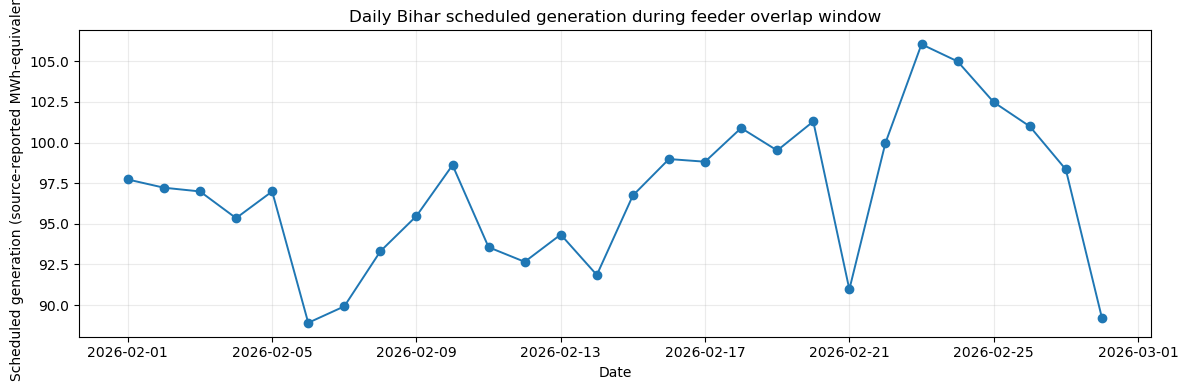

Saved chart: F:\Secure\CashFlowMgmt\data\33kv_incoming_feeder_generation_daily_context.png


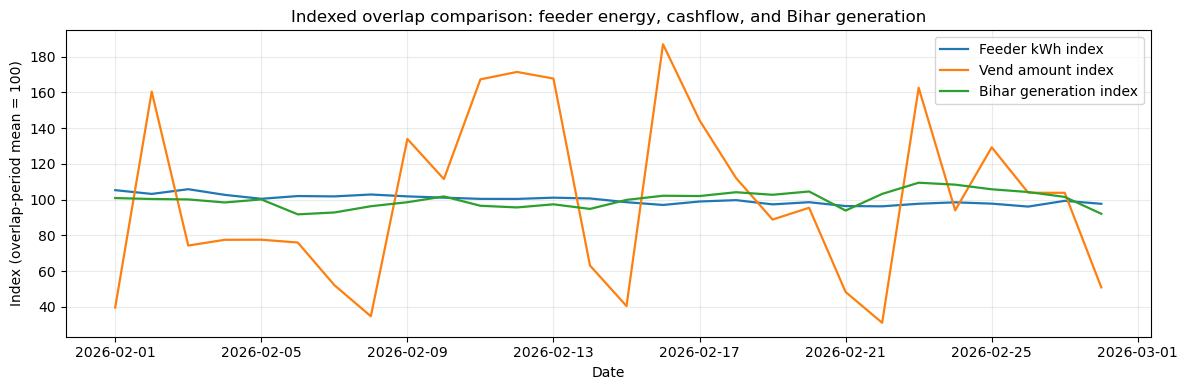

Saved chart: F:\Secure\CashFlowMgmt\data\33kv_incoming_feeder_generation_indexed_overlap.png


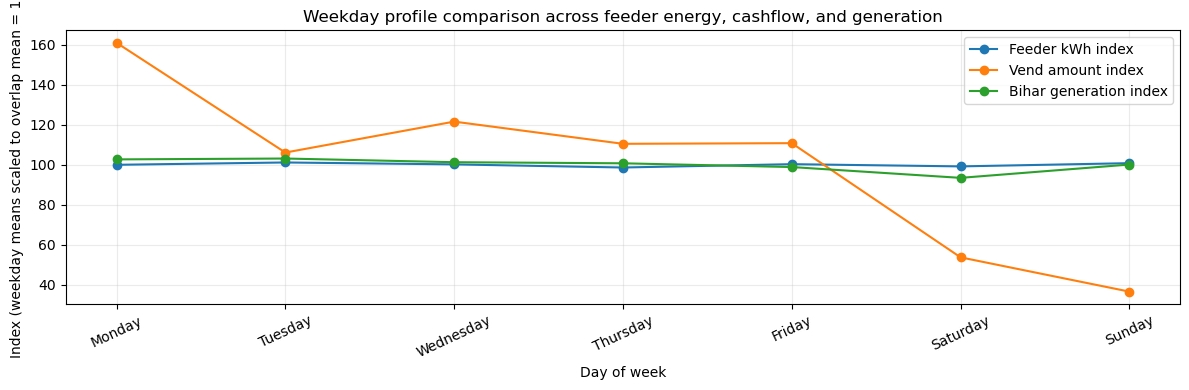

Saved chart: F:\Secure\CashFlowMgmt\data\33kv_incoming_feeder_generation_weekday_profile.png


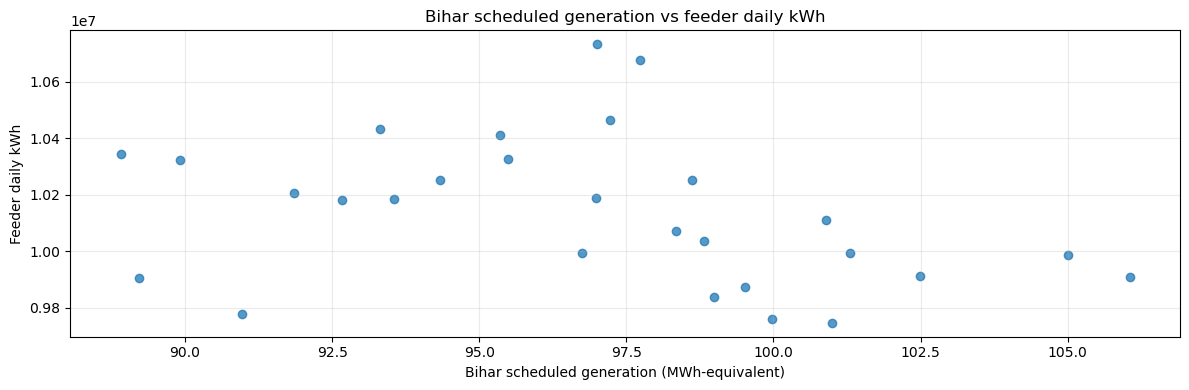

Saved chart: F:\Secure\CashFlowMgmt\data\33kv_incoming_feeder_generation_vs_feeder_scatter.png


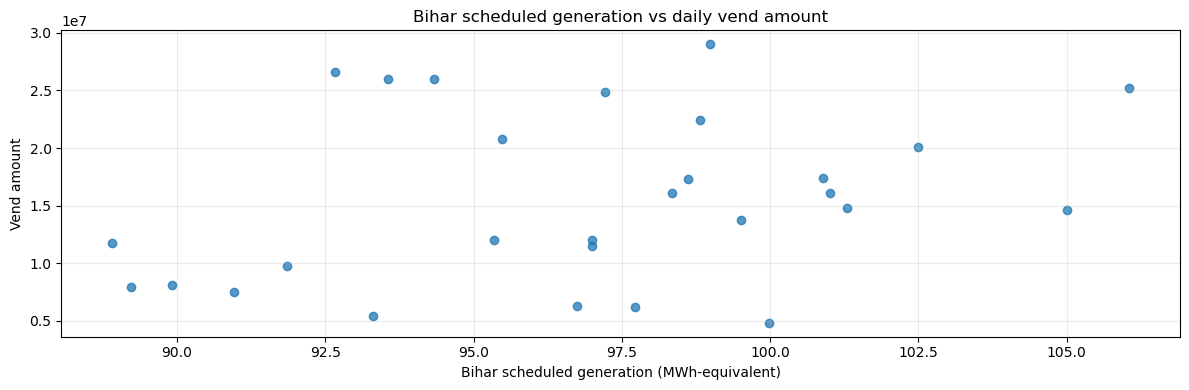

Saved chart: F:\Secure\CashFlowMgmt\data\33kv_incoming_feeder_generation_vs_vend_scatter.png


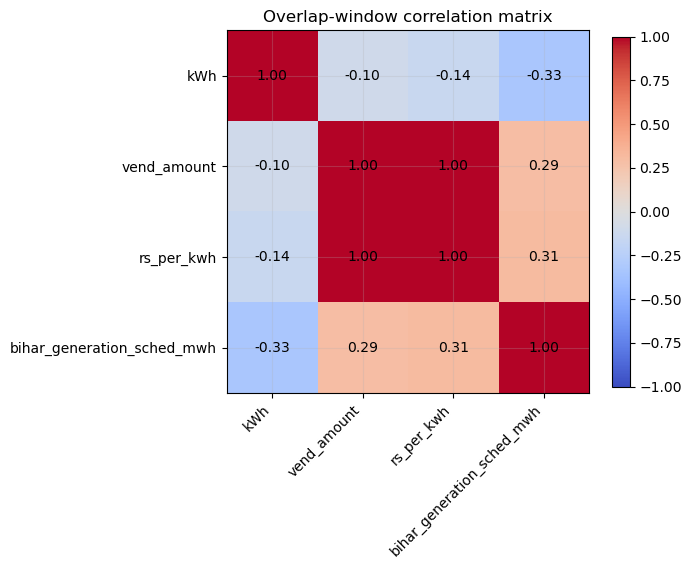

Saved chart: F:\Secure\CashFlowMgmt\data\33kv_incoming_feeder_generation_correlation.png


In [6]:
plt.figure()
plt.plot(overlap_daily['date'], overlap_daily['bihar_generation_sched_mwh'], marker='o', linewidth=1.4)
plt.title('Daily Bihar scheduled generation during feeder overlap window')
plt.xlabel('Date')
plt.ylabel('Scheduled generation (source-reported MWh-equivalent)')
save_line_chart(GENERATION_DAILY_CHART_PATH)

plt.figure()
plt.plot(overlap_daily['date'], overlap_daily['feeder_kwh_index'], linewidth=1.6, label='Feeder kWh index')
plt.plot(overlap_daily['date'], overlap_daily['vend_amount_index'], linewidth=1.6, label='Vend amount index')
plt.plot(overlap_daily['date'], overlap_daily['generation_index'], linewidth=1.6, label='Bihar generation index')
plt.title('Indexed overlap comparison: feeder energy, cashflow, and Bihar generation')
plt.xlabel('Date')
plt.ylabel('Index (overlap-period mean = 100)')
plt.legend()
save_line_chart(INDEXED_CHART_PATH)

plt.figure()
plt.plot(weekday_profile['DayOfWeek'].astype(str), weekday_profile['feeder_kwh_index'], marker='o', linewidth=1.5, label='Feeder kWh index')
plt.plot(weekday_profile['DayOfWeek'].astype(str), weekday_profile['vend_amount_index'], marker='o', linewidth=1.5, label='Vend amount index')
plt.plot(weekday_profile['DayOfWeek'].astype(str), weekday_profile['generation_index'], marker='o', linewidth=1.5, label='Bihar generation index')
plt.title('Weekday profile comparison across feeder energy, cashflow, and generation')
plt.xlabel('Day of week')
plt.ylabel('Index (weekday means scaled to overlap mean = 100)')
plt.xticks(rotation=25)
plt.legend()
save_line_chart(WEEKDAY_CHART_PATH)

plt.figure()
plt.scatter(overlap_daily['bihar_generation_sched_mwh'], overlap_daily['kWh'], alpha=0.75)
plt.title('Bihar scheduled generation vs feeder daily kWh')
plt.xlabel('Bihar scheduled generation (MWh-equivalent)')
plt.ylabel('Feeder daily kWh')
save_line_chart(GEN_VS_FEEDER_SCATTER_PATH)

plt.figure()
plt.scatter(overlap_daily['bihar_generation_sched_mwh'], overlap_daily['vend_amount'], alpha=0.75)
plt.title('Bihar scheduled generation vs daily vend amount')
plt.xlabel('Bihar scheduled generation (MWh-equivalent)')
plt.ylabel('Vend amount')
save_line_chart(GEN_VS_VEND_SCATTER_PATH)

render_corr_heatmap(correlation_df, 'Overlap-window correlation matrix', CORRELATION_CHART_PATH)

## Reporting notes

Use this extension carefully:

- the comparison window is limited to the daily overlap between the feeder summary and the Bihar generation output
- feeder `kWh` and Bihar scheduled generation are not the same scope, so the indexed and correlation views are more meaningful than raw level comparisons
- the current Bihar import file is empty, so this extension focuses on generation context rather than full state net-supply reconstruction
- if the Bihar mapping table changes, rerun the Bihar notebook first and then rerun this extension notebook